# SECTION 2 — Python Data Analytics and Machine Learning

This section uses Python, Pandas, NumPy, visualisation, feature engineering, and machine learning to analyse NorthStar’s operational failures from a business perspective.

In [ ]:
import pandas as pd                              # Data manipulation and analysis
import numpy as np                               # Numerical computing
import matplotlib.pyplot as plt                  # Visualisation

from sklearn.model_selection import train_test_split    # ML train/test split
from sklearn.preprocessing import LabelEncoder          # Categorical encoding
from sklearn.metrics import (accuracy_score,            # ML evaluation metrics
                             classification_report,
                             confusion_matrix)
from sklearn.ensemble import RandomForestClassifier     # Random Forest model
from sklearn.linear_model import LogisticRegression     # Logistic Regression model


In [ ]:
#Load cleaned dataset from Github
BASE = "https://raw.githubusercontent.com/rizmiya-gith/NorthStar-Analytics/main/cleaned_data/"

deliveries = pd.read_csv(BASE + "deliveries_cleaned.csv")
orders = pd.read_csv(BASE + "orders_cleaned.csv")
drivers = pd.read_csv(BASE + "drivers_cleaned.csv")
vehicles = pd.read_csv(BASE + "vehicles_cleaned.csv")
hubs = pd.read_csv(BASE + "hubs_cleaned.csv")
incidents = pd.read_csv(BASE + "incidents_cleaned.csv")
complaints = pd.read_csv(BASE + "complaints_cleaned.csv")
customers = pd.read_csv(BASE + "customers_cleaned.csv")
app_events = pd.read_csv(BASE + "app_events_cleaned.csv")

In [ ]:
#Verify loading
datasets = {
    "deliveries": deliveries,
    "orders": orders,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "incidents": incidents,
    "complaints": complaints,
    "customers": customers,
    "app_events": app_events
}

for name, df in datasets.items():
    print(name, df.shape)

deliveries (950, 13)
orders (1250, 11)
drivers (170, 8)
vehicles (120, 8)
hubs (8, 5)
incidents (280, 7)
complaints (320, 10)
customers (650, 9)
app_events (640, 10)


In [ ]:
#Data overview
deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,False,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,False,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,False,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,False,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,False,4.18,9.22


In [ ]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   delivery_id                    950 non-null    object 
 1   order_id                       950 non-null    object 
 2   driver_id                      950 non-null    object 
 3   vehicle_id                     950 non-null    object 
 4   hub_id                         950 non-null    object 
 5   dispatch_time                  950 non-null    object 
 6   delivery_completed_at          931 non-null    object 
 7   delivery_status                950 non-null    object 
 8   route_distance_km              950 non-null    float64
 9   manual_route_override_count    950 non-null    int64  
 10  proof_of_completion_missing    950 non-null    bool   
 11  customer_rating_post_delivery  950 non-null    float64
 12  fuel_or_charge_cost            950 non-null    flo

In [ ]:
deliveries.describe()

,route_distance_km,manual_route_override_count,customer_rating_post_delivery,fuel_or_charge_cost
count,950.000000,950.000000,950.000000,950.000000
mean,13.909316,0.969474,3.864679,12.841295
std,7.477907,1.093189,0.887798,4.336468
min,1.200000,0.000000,1.000000,2.500000
25%,9.135000,0.000000,3.372500,9.925000
50%,12.840000,1.000000,4.030000,12.645000
75%,16.835000,2.000000,4.550000,15.697500
max,41.940000,7.000000,5.000000,29.430000


In [ ]:
#missing values duplicate
for name, df in datasets.items():
    print("\n", name)
    print("Missing values:", df.isnull().sum().sum())
    print("Duplicates:", df.duplicated().sum())


 deliveries
Missing values: 19
Duplicates: 0

 orders
Missing values: 0
Duplicates: 0

 drivers
Missing values: 0
Duplicates: 0

 vehicles
Missing values: 0
Duplicates: 0

 hubs
Missing values: 0
Duplicates: 0

 incidents
Missing values: 17
Duplicates: 0

 complaints
Missing values: 0
Duplicates: 0

 customers
Missing values: 0
Duplicates: 0

 app_events
Missing values: 144
Duplicates: 0


In [ ]:
#delivery status EDA
deliveries["delivery_status"].value_counts()

,count
delivery_status,
OnTime,616
Delayed,202
Failed,132


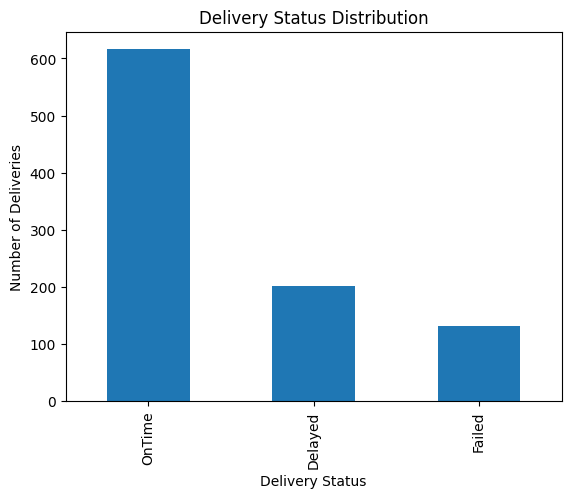

In [ ]:
deliveries["delivery_status"].value_counts().plot(kind="bar")

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")
plt.show()

### Business Interpretation

This graph shows the overall delivery performance of NorthStar. Failed and delayed deliveries represent operational inefficiency and directly affect customer satisfaction.

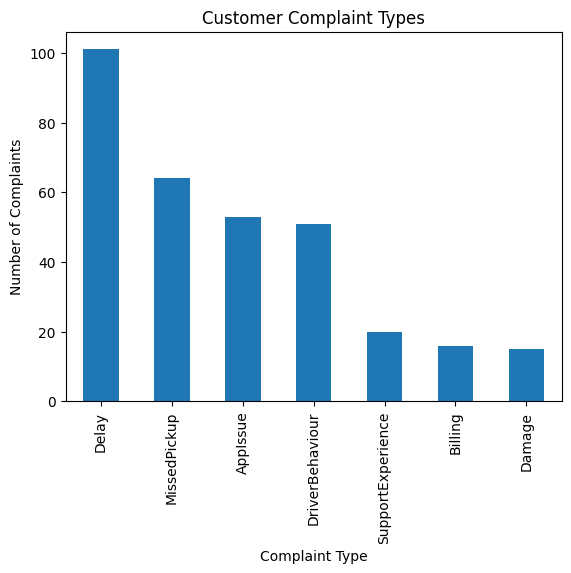

In [ ]:
#Complaint analysis
complaints["complaint_type"].value_counts().plot(kind="bar")

plt.title("Customer Complaint Types")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")
plt.show()

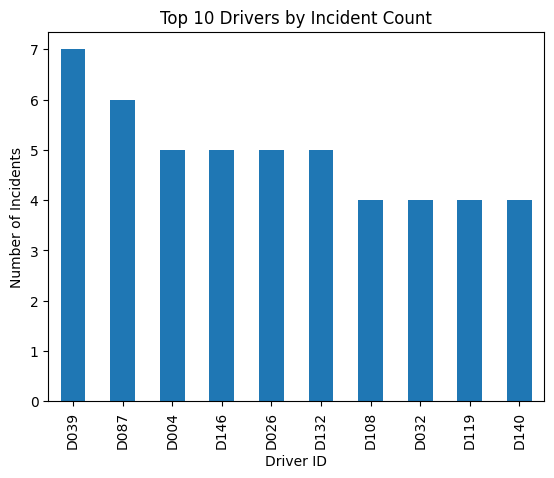

In [ ]:
# Merge incidents with deliveries to get driver IDs
incident_driver = incidents.merge(
    deliveries[["delivery_id", "driver_id"]],
    on="delivery_id",
    how="left"
)

# Count incidents per driver
incident_driver["driver_id"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Drivers by Incident Count")
plt.xlabel("Driver ID")
plt.ylabel("Number of Incidents")
plt.show()

In [ ]:
#merge dataset
# Aggregate incident counts per delivery
incident_counts = incidents.groupby("delivery_id").size().reset_index(name="incident_count")

# Build master analytical DataFrame
df = deliveries.merge(orders, on="order_id", how="left")
df = df.merge(drivers, on="driver_id", how="left")
df = df.merge(vehicles, on="vehicle_id", how="left")
df = df.merge(hubs, on="hub_id", how="left")
df = df.merge(incident_counts, on="delivery_id", how="left")

df["incident_count"] = df["incident_count"].fillna(0)

df.shape

(950, 42)

In [ ]:
#Feature engineering
# 1. Binary delivery failure flag (target variable for ML)
df["delivery_failed"] = (df["delivery_status"] == "Failed").astype(int)

# 2. Whether this delivery's order generated a customer complaint
df["generated_complaint"] = df["order_id"].isin(complaints["order_id"]).astype(int)

# 3. Driver risk flag — above-average incident history
df["driver_risk_flag"] = (df["incident_count"] > df["incident_count"].mean()).astype(int)


# Machine Learning Problem Type

The target variable is `delivery_failed`.

Since the target has two outcomes, 0 for not failed and 1 for failed, this is a binary classification problem.

The business goal is to predict whether a delivery is likely to fail so that NorthStar can take preventive action before the failure occurs.

In [ ]:
#Prepare ML dataset
features = [
    "route_distance_km",
    "manual_route_override_count",
    "fuel_or_charge_cost",
    "proof_of_completion_missing",
    "incident_count",
    "driver_rating",
    "training_score",
    "years_experience",
    "battery_health_pct",
    "odometer_km",
    "order_value",
    "capacity_score"
]

target = "delivery_failed"

ml_df = df[features + [target]].copy()
ml_df = ml_df.fillna(ml_df.median(numeric_only=True))

In [ ]:
#Train/test split
X = ml_df[features]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [ ]:
X = ml_df[features]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y          # Maintains class proportions in both splits
)

# Training set: 712 records | Test set: 238 records
# Failed in test set: 33 records (13.9%)


In [ ]:
#Model 1: Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.8613445378151261
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       205
           1       0.00      0.00      0.00        33

    accuracy                           0.86       238
   macro avg       0.43      0.50      0.46       238
weighted avg       0.74      0.86      0.80       238



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

In [ ]:
#Model 2: Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8613445378151261
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       205
           1       0.00      0.00      0.00        33

    accuracy                           0.86       238
   macro avg       0.43      0.50      0.46       238
weighted avg       0.74      0.86      0.80       238



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


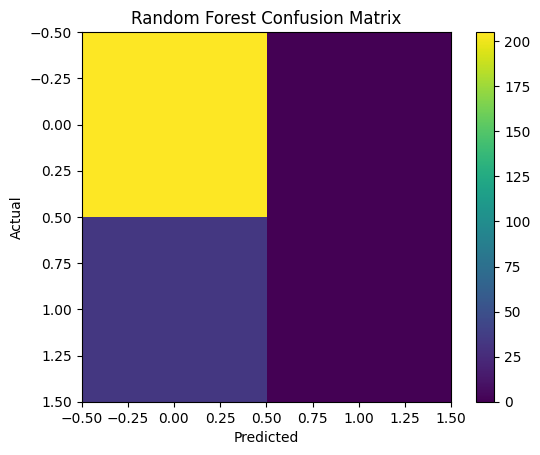

array([[205,   0],
       [ 33,   0]])

In [ ]:
#Confusin Matrix
cm = confusion_matrix(y_test, rf_pred)

plt.imshow(cm)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

cm

In [ ]:
#feature importance
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
10,order_value,0.128422
2,fuel_or_charge_cost,0.116065
9,odometer_km,0.113977
0,route_distance_km,0.112941
5,driver_rating,0.105148
8,battery_health_pct,0.104109
6,training_score,0.085219
11,capacity_score,0.070370
7,years_experience,0.068153
1,manual_route_override_count,0.041721


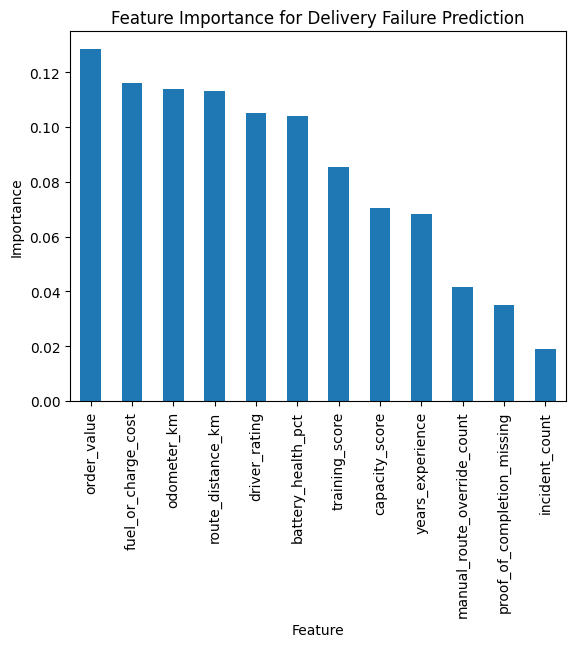

In [ ]:
importance.plot(x="Feature", y="Importance", kind="bar", legend=False)

plt.title("Feature Importance for Delivery Failure Prediction")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()

### Business Interpretation

The feature importance analysis shows which operational factors contribute most to delivery failure. NorthStar can use these factors to prioritise route planning, driver monitoring, vehicle maintenance, and hub capacity management.

In [ ]:
print("""
SECTION 2 KEY FINDINGS

1. Failed and delayed deliveries are major operational problems.
2. Complaint patterns show customer dissatisfaction is linked to service reliability.
3. Driver incidents help identify operational risk.
4. Machine learning was applied as a classification problem to predict delivery failure.
5. Random Forest was used to identify the most important operational risk factors.
""")


SECTION 2 KEY FINDINGS

1. Failed and delayed deliveries are major operational problems.
2. Complaint patterns show customer dissatisfaction is linked to service reliability.
3. Driver incidents help identify operational risk.
4. Machine learning was applied as a classification problem to predict delivery failure.
5. Random Forest was used to identify the most important operational risk factors.

